In [2]:
import sys, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset, random_split
try:
    import cv2
    print("OpenCV:", cv2.__version__)
except ImportError:
    cv2 = None
    print("OpenCV not found (only needed for the optional photo test)")
SEED = 42 # fixed seed so your results are repeatable
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

OpenCV: 4.11.0


In [3]:
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__, "| torchvision:", torchvision.__version__)
print("Training on:", device)

Python: 3.11.5
PyTorch: 2.5.1 | torchvision: 0.20.1
Training on: cpu


In [4]:
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
'dog', 'frog', 'horse', 'ship', 'truck']
MEAN, STD = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
tf = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])
train_full = torchvision.datasets.CIFAR10("./data", train=True, download=True, transform=tf)
test_set = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=tf)
# 45,000 for training, 5,000 for validation
train_set, val_set = random_split(
train_full, [45000, 5000], generator=torch.Generator().manual_seed(SEED))
BATCH = 128
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=BATCH, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=BATCH, shuffle=False, num_workers=2)
print("train / val / test sizes:", len(train_set), len(val_set), len(test_set))

100%|██████████| 170M/170M [00:41<00:00, 4.08MB/s]   


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified
train / val / test sizes: 45000 5000 10000


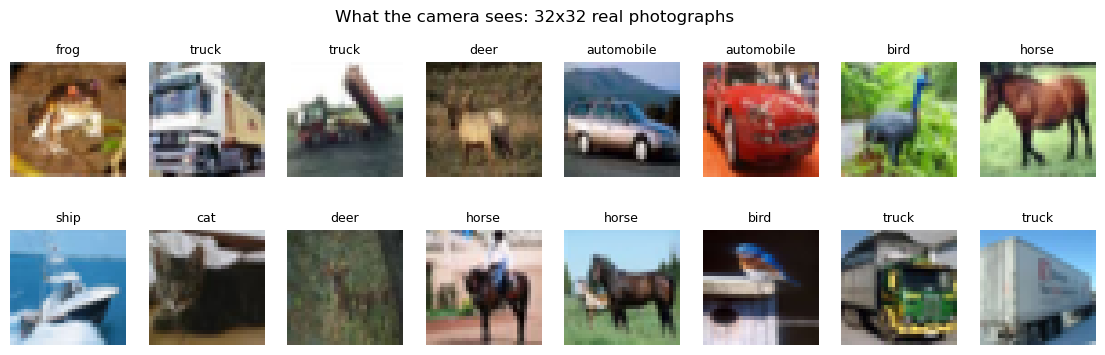

Images per class: {'airplane': 5000, 'automobile': 5000, 'bird': 5000, 'cat': 5000, 'deer': 5000, 'dog': 5000, 'frog': 5000, 'horse': 5000, 'ship': 5000, 'truck': 5000}


In [5]:
raw = torchvision.datasets.CIFAR10("./data", train=True, download=False) # PIL images
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, i in zip(axes.flat, range(16)):
    img, label = raw[i]
    ax.imshow(img)
    ax.set_title(CLASSES[label], fontsize=9)
    ax.axis("off")
plt.suptitle("What the camera sees: 32x32 real photographs")
plt.show()
print("Images per class:", dict(zip(CLASSES, np.bincount(raw.targets))))

In [6]:
images, labels = next(iter(train_loader))
print("images:", images.shape, "| labels:", labels.shape)
print("pixel range after normalisation: %.2f to %.2f" % (images.min(), images.max()))

images: torch.Size([128, 3, 32, 32]) | labels: torch.Size([128])
pixel range after normalisation: -1.99 to 2.13


In [7]:
class SceneCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
        nn.Linear(256, num_classes), # raw scores (logits), no softmax here
        )
    def forward(self, x):
        return self.classifier(self.features(x))
model = SceneCNN().to(device)
print(model)

SceneCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [8]:
x = torch.randn(1, 3, 32, 32).to(device) # one fake 32x32 colour image
for layer in model.features:
    x = layer(x)
    print(f"{layer.__class__.__name__:<10} -> {tuple(x.shape)}")
print("Flattened length fed to the classifier:", x.numel())

Conv2d     -> (1, 32, 32, 32)
ReLU       -> (1, 32, 32, 32)
MaxPool2d  -> (1, 32, 16, 16)
Conv2d     -> (1, 64, 16, 16)
ReLU       -> (1, 64, 16, 16)
MaxPool2d  -> (1, 64, 8, 8)
Conv2d     -> (1, 128, 8, 8)
ReLU       -> (1, 128, 8, 8)
MaxPool2d  -> (1, 128, 4, 4)
Flattened length fed to the classifier: 2048


In [9]:
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

mlp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3 * 32 * 32, 1024),
    nn.ReLU(),
    nn.Linear(1024, 10)
)

print(f"SceneCNN parameters : {count_params(model):>10,}")
print(f"Plain MLP parameters: {count_params(mlp):>10,}")
print()

for name, p in model.named_parameters():
    print(f"{name:<22}{str(tuple(p.shape)):<20}{p.numel():>9,}")

SceneCNN parameters :    620,362
Plain MLP parameters:  3,157,002

features.0.weight     (32, 3, 3, 3)             864
features.0.bias       (32,)                      32
features.3.weight     (64, 32, 3, 3)         18,432
features.3.bias       (64,)                      64
features.6.weight     (128, 64, 3, 3)        73,728
features.6.bias       (128,)                    128
classifier.1.weight   (256, 2048)           524,288
classifier.1.bias     (256,)                    256
classifier.3.weight   (10, 256)               2,560
classifier.3.bias     (10,)                      10


In [10]:
layers = [
    ("conv1", 3, 1),
    ("pool1", 2, 2),
    ("conv2", 3, 1),
    ("pool2", 2, 2),
    ("conv3", 3, 1),
    ("pool3", 2, 2)
]

r, j = 1, 1

for name, k, s in layers:
    r = r + (k - 1) * j
    j = j * s
    print(
        f"{name}: each neuron sees a {r} x {r} patch "
        "of the original image"
    )

conv1: each neuron sees a 3 x 3 patch of the original image
pool1: each neuron sees a 4 x 4 patch of the original image
conv2: each neuron sees a 8 x 8 patch of the original image
pool2: each neuron sees a 10 x 10 patch of the original image
conv3: each neuron sees a 18 x 18 patch of the original image
pool3: each neuron sees a 22 x 22 patch of the original image


In [11]:
criterion = nn.CrossEntropyLoss()

images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

model.zero_grad()

loss = criterion(model(images), labels)
loss.backward()

print(
    f"Initial loss: {loss.item():.3f} "
    f"(guessing = ln(10) = {np.log(10):.3f})"
)

for name, p in model.named_parameters():
    if "weight" in name:
        print(
            f"{name:<22} gradient norm = "
            f"{p.grad.norm().item():.4f}"
        )

Initial loss: 2.300 (guessing = ln(10) = 2.303)
features.0.weight      gradient norm = 0.0171
features.3.weight      gradient norm = 0.0652
features.6.weight      gradient norm = 0.0953
classifier.1.weight    gradient norm = 0.2220
classifier.3.weight    gradient norm = 0.0808


In [12]:
EPOCHS = 8 if device.type != "cpu" else 4

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

def run_epoch(loader, train):
    model.train(train)

    total_loss = 0.0
    correct = 0
    n = 0

    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)

    return total_loss / n, correct / n


history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    tl, ta = run_epoch(train_loader, train=True)
    vl, va = run_epoch(val_loader, train=False)

    for k, v in zip(history, (tl, vl, ta, va)):
        history[k].append(v)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"train loss {tl:.3f} acc {ta:.1%} | "
        f"val loss {vl:.3f} acc {va:.1%} | "
        f"{time.time() - t0:.0f}s"
    )

Epoch 1/4 | train loss 1.781 acc 34.9% | val loss 1.482 acc 46.7% | 38s
Epoch 2/4 | train loss 1.286 acc 53.8% | val loss 1.147 acc 58.1% | 36s
Epoch 3/4 | train loss 1.042 acc 63.1% | val loss 0.990 acc 64.5% | 36s
Epoch 4/4 | train loss 0.867 acc 69.7% | val loss 0.863 acc 70.3% | 40s


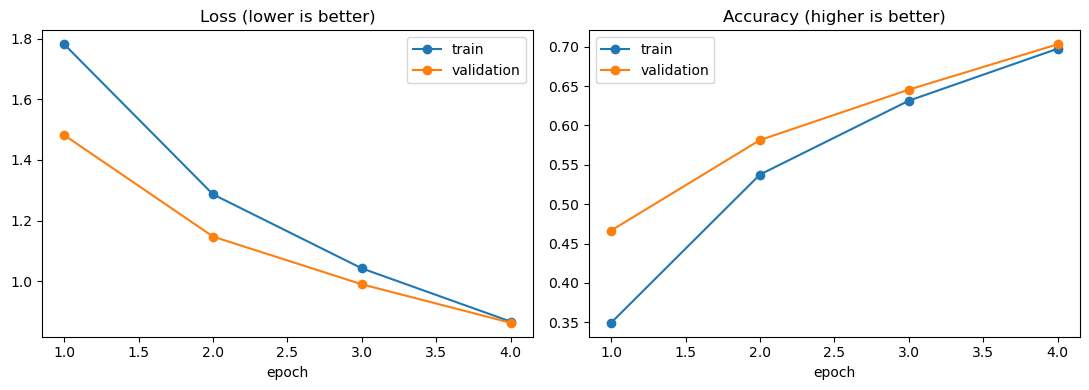

Saved model to scene_cnn_week3.pth


In [13]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(epochs, history["train_loss"], "o-", label="train")
ax[0].plot(epochs, history["val_loss"], "o-", label="validation")
ax[0].set_title("Loss (lower is better)")
ax[0].set_xlabel("epoch")
ax[0].legend()

ax[1].plot(epochs, history["train_acc"], "o-", label="train")
ax[1].plot(epochs, history["val_acc"], "o-", label="validation")
ax[1].set_title("Accuracy (higher is better)")
ax[1].set_xlabel("epoch")
ax[1].legend()

plt.tight_layout()
plt.show()

torch.save(model.state_dict(), "scene_cnn_week3.pth")
print("Saved model to scene_cnn_week3.pth")

In [14]:
@torch.no_grad()
def predict_all(loader):
    model.eval()

    probs, ys = [], []

    for x, y in loader:
        probs.append(
            F.softmax(model(x.to(device)), dim=1).cpu()
        )
        ys.append(y)

    return torch.cat(probs), torch.cat(ys)


probs, ys = predict_all(test_loader)
preds = probs.argmax(1)

test_accuracy = (preds == ys).float().mean().item()

print(f"Test accuracy: {test_accuracy:.2%}")

Test accuracy: 69.54%


Per-class accuracy:
airplane   65.1%
automobile 87.4%
bird       45.7%
cat        46.5%
deer       58.5%
dog        69.0%
frog       87.4%
horse      74.2%
ship       80.5%
truck      81.1%


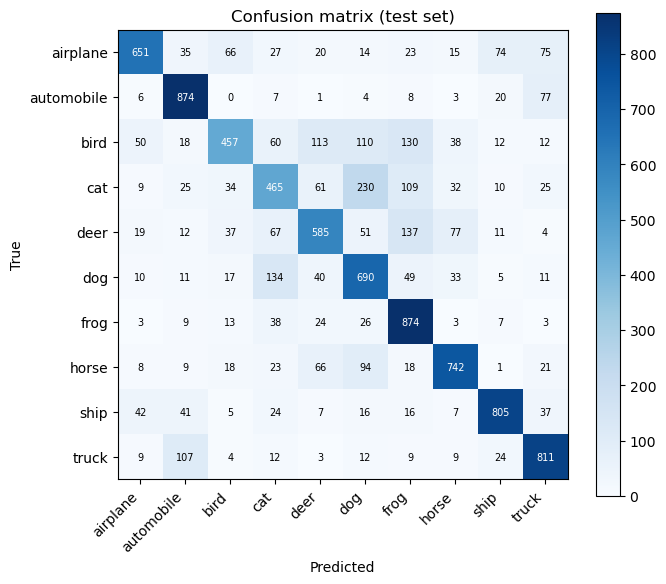


Three most common mistakes:
 cat predicted as dog: 230 times
 deer predicted as frog: 137 times
 dog predicted as cat: 134 times


In [15]:
cm = np.zeros((10, 10), dtype=int)

# Rows = true class, columns = predicted class.
for t, p_ in zip(ys.numpy(), preds.numpy()):
    cm[t, p_] += 1

print("Per-class accuracy:")

for c, a in zip(CLASSES, cm.diagonal() / cm.sum(1)):
    print(f"{c:<11}{a:.1%}")

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(10))
ax.set_xticklabels(CLASSES, rotation=45, ha="right")

ax.set_yticks(range(10))
ax.set_yticklabels(CLASSES)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (test set)")

for i in range(10):
    for j in range(10):
        ax.text(
            j, i, cm[i, j],
            ha="center",
            va="center",
            fontsize=7,
            color="white" if cm[i, j] > cm.max() / 2 else "black"
        )

plt.colorbar(im)
plt.tight_layout()
plt.show()

off = cm.copy()
np.fill_diagonal(off, 0)

print("\nThree most common mistakes:")

for idx in np.argsort(-off.ravel())[:3]:
    t, p_ = divmod(idx, 10)
    print(
        f" {CLASSES[t]} predicted as {CLASSES[p_]}: "
        f"{off[t, p_]} times"
    )

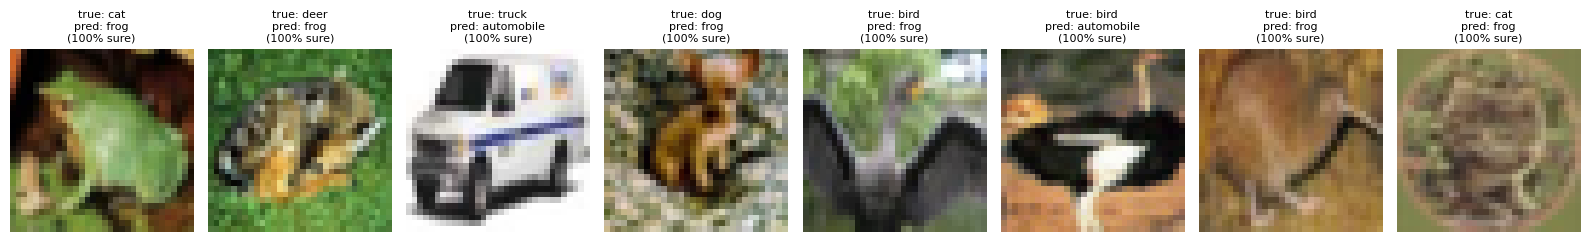

In [16]:
conf, _ = probs.max(1)

wrong = (preds != ys).nonzero().flatten()

if len(wrong) > 0:
    worst = wrong[conf[wrong].argsort(descending=True)[:8]]

    raw_test = torchvision.datasets.CIFAR10(
        "./data", train=False, download=False
    )

    fig, axes = plt.subplots(1, len(worst), figsize=(16, 3))

    if len(worst) == 1:
        axes = [axes]

    for ax, idx in zip(axes, worst.tolist()):
        img, _ = raw_test[idx]

        ax.imshow(img)
        ax.axis("off")
        ax.set_title(
            f"true: {CLASSES[ys[idx]]}\n"
            f"pred: {CLASSES[preds[idx]]}\n"
            f"({conf[idx]:.0%} sure)",
            fontsize=8
        )

    plt.tight_layout()
    plt.show()
else:
    print("No incorrect predictions were found.")

In [17]:
VEHICLES = torch.tensor([0, 1, 8, 9])

true_vehicle = torch.isin(ys, VEHICLES)
pred_vehicle = torch.isin(preds, VEHICLES)

object_accuracy = (preds == ys).float().mean().item()
scene_accuracy = (true_vehicle == pred_vehicle).float().mean().item()

print(f"10-class (object-level) accuracy : {object_accuracy:.2%}")
print(f"Vehicle vs animal (scene-level) : {scene_accuracy:.2%}")

10-class (object-level) accuracy : 69.54%
Vehicle vs animal (scene-level) : 93.83%


In [18]:
def out_size(h, k, p, s):
    return (h + 2 * p - k) // s + 1


for k, p_, s in [
    (3, 0, 1),
    (3, 0, 2),
    (3, 1, 1),
    (3, 1, 2)
]:
    real = nn.Conv2d(
        3, 8,
        kernel_size=k,
        padding=p_,
        stride=s
    )(torch.randn(1, 3, 32, 32))

    print(
        f"kernel={k} padding={p_} stride={s}: "
        f"formula {out_size(32, k, p_, s)} | "
        f"PyTorch {real.shape[-1]}"
    )

kernel=3 padding=0 stride=1: formula 30 | PyTorch 30
kernel=3 padding=0 stride=2: formula 15 | PyTorch 15
kernel=3 padding=1 stride=1: formula 32 | PyTorch 32
kernel=3 padding=1 stride=2: formula 16 | PyTorch 16


In [20]:
# Fix the missing variable used by the learning-rate test
NUM_WORKERS = 2  # matches the earlier DataLoader setup

# Re-run the quick LR sweep using the corrected workers setting
sub_loader = DataLoader(
    Subset(train_set, range(10000)),
    batch_size=BATCH,
    shuffle=True,
    num_workers=NUM_WORKERS
)


def quick_lr_test(lr, epochs=2):
    torch.manual_seed(SEED)

    m = SceneCNN().to(device)
    opt = torch.optim.SGD(m.parameters(), lr=lr, momentum=0.9)

    for _ in range(epochs):
        m.train()
        for x, y in sub_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = criterion(m(x), y)
            loss.backward()
            opt.step()

    m.eval()
    correct = 0
    with torch.no_grad():
        for x, y in val_loader:
            pred = m(x.to(device)).argmax(1).cpu()
            correct += (pred == y).sum().item()

    return loss.item(), correct / len(val_set)


for lr in [0.1, 0.01, 0.001]:
    last_loss, val_acc = quick_lr_test(lr)
    print(f"lr = {lr:<6} final batch loss = {last_loss:.3f} validation accuracy = {val_acc:.1%}")

lr = 0.1    final batch loss = 1.440 validation accuracy = 39.7%
lr = 0.01   final batch loss = 1.731 validation accuracy = 38.5%
lr = 0.001  final batch loss = 2.299 validation accuracy = 12.4%


In [1]:
from IPython.display import Markdown, display

display(Markdown(
"""
## Data loading
CIFAR-10 is normalized and split into train, validation, and test sets so the model can be trained and evaluated fairly.

## CNN model
A compact convolutional network learns spatial patterns from the 32x32 RGB images.

## Training
The model is optimized with SGD while tracking loss and accuracy over multiple epochs.

## Evaluation
We check test accuracy, confusion patterns, and the most common misclassifications to understand model behavior.
"""
))


## Data loading
CIFAR-10 is normalized and split into train, validation, and test sets so the model can be trained and evaluated fairly.

## CNN model
A compact convolutional network learns spatial patterns from the 32x32 RGB images.

## Training
The model is optimized with SGD while tracking loss and accuracy over multiple epochs.

## Evaluation
We check test accuracy, confusion patterns, and the most common misclassifications to understand model behavior.
